In [7]:
# ### 1. Import Libraries and Configuration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from matplotlib.ticker import MultipleLocator
from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem
from pathlib import Path
import os

In [9]:
# %% matplotlib inline
sns.set_theme(style="whitegrid")

# Helper function to compute descriptors
def _compute_properties(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        return {
            'MW': Descriptors.MolWt(mol),
            'AlogP': Descriptors.MolLogP(mol),
            'HBD': Descriptors.NumHDonors(mol),
            'HBA': Descriptors.NumHAcceptors(mol)
        }
    return {'MW': None, 'AlogP': None, 'HBD': None, 'HBA': None}

# Function to clean SMILES (remove salts, canonicalize)
def clean_smiles(smiles):
    if pd.isna(smiles): return None
    mol = Chem.MolFromSmiles(smiles)
    if not mol: return None
    frags = Chem.GetMolFrags(mol, asMols=True)
    largest = max(frags, key=lambda x: x.GetNumHeavyAtoms())
    return Chem.MolToSmiles(largest, isomericSmiles=True)

print("Setup complete. Functions defined.")

Setup complete. Functions defined.


In [10]:
# %%
# ### 2. Read and Merge Data (check the current working directory)
act_path = "NSD2_chembl_act_2124.csv"
com_path = "NSD2_chembl_com_1265.csv"

'''
if not os.path.exists(act_path):
    act_path = "../data/NSD2/NSD2_chembl_act_2124.csv"
    com_path = "../data/NSD2/NSD2_chembl_com_1265.csv"
'''

df_act = pd.read_csv(act_path)
df_com = pd.read_csv(com_path)

# Unified column names to lowercase
df_act.columns = [c.lower().replace(' ', '_') for c in df_act.columns]
df_com.columns = [c.lower().replace(' ', '_') for c in df_com.columns]

if 'chembl_id' in df_com.columns:
    df_com = df_com.rename(columns={'chembl_id': 'molecule_chembl_id'})

# Inner merge on molecule_chembl_id
merged = df_act.merge(df_com, on='molecule_chembl_id', how='inner', suffixes=('', '_drop'))
merged = merged.drop(columns=[c for c in merged.columns if c.endswith('_drop')])

print(f"Merged Data: {merged.shape}")
merged.head(2)

Merged Data: (2124, 72)


,molecule_chembl_id,molecule_name,molecule_max_phase,molecular_weight,#ro5_violations,alogp,compound_key,smiles,standard_type,standard_relation,...,inorganic_flag,heavy_atoms,np_likeness_score,molecular_formula,inchi_key,inchi,withdrawn_flag,orphan,records_key,records_name
0,CHEMBL5986329,NaN,NaN,561.64,1.0,3.50,BDBM567886,CC1CCCCN1C(=O)C1(N)CCCN(c2cnc(-c3ccc(F)c(F)c3)...,kon,'=',...,-1,41.0,-1.06,C29H33F2N9O,GJSQTKUYSJUOKI-UHFFFAOYSA-N,InChI=1S/C29H33F2N9O/c1-18-5-2-3-10-40(18)28(4...,False,-1,['BDBM567886'],"['US11420970, Example 87']"
1,CHEMBL6063957,NaN,NaN,494.55,0.0,3.13,BDBM567894,CO[C@@H](C)[C@@]1(N)CCCN(c2cnc(-c3ccc(F)c(F)c3...,k_off,'=',...,-1,36.0,-0.88,C25H28F2N8O,GSBRBMILDDIXOW-ODCWNRFASA-N,InChI=1S/C25H28F2N8O/c1-15(36-2)25(29)6-3-7-34...,False,-1,['BDBM567894'],"['US11420970, Example 95']"


In [11]:
# ### 3. Bioactivity Filtering and SMILES Cleaning

# 1. Filter IC50 and nM units
df_ic50 = merged[(merged['standard_type'].str.upper() == 'IC50') & 
                 (merged['standard_units'].str.lower() == 'nm') &
                 (merged['standard_relation'] == "'='")
].copy()

# 2. Convert value to numeric and drop NAs
df_ic50['standard_value'] = pd.to_numeric(df_ic50['standard_value'], errors='coerce')
df_ic50 = df_ic50.dropna(subset=['standard_value'])

# 3. Calculate pIC50
df_ic50['pIC50'] = -np.log10(df_ic50['standard_value'] * 1e-9)
# 过滤掉 pIC50 小于 3 的分子 
# 1mM (pIC50=3) 已经是药物筛选中极低活性的极限了，低于这个值的分子没有统计意义
before_pic50_filter = len(df_ic50)
df_ic50 = df_ic50[df_ic50['pIC50'] >= 3.0]
removed_pic50_lt_3 = before_pic50_filter - len(df_ic50)
print(f"Removed {removed_pic50_lt_3} records with pIC50 < 3")

# 4. Canonicalize SMILES and remove salts
print("Cleaning SMILES (Removing salts)...")
df_ic50['canonical_smiles'] = df_ic50['smiles'].apply(clean_smiles)
df_ic50 = df_ic50.dropna(subset=['canonical_smiles'])

# 5. Aggregate duplicates by median pIC50
final_df = df_ic50.groupby('canonical_smiles').agg({
    'molecule_chembl_id': 'first',
    'pIC50': 'median',
    'standard_value': 'median'
}).reset_index()

# 6. Label activity #### Adjust Threshold if necessary
final_df['label'] = np.where(final_df['pIC50'] >= 6.0, '1', '0') ##### 1 for Active, 0 for Inactive

print(f"Unique Molecules after cleaning: {len(final_df)}")

Removed 0 records with pIC50 < 3
Cleaning SMILES (Removing salts)...
Unique Molecules after cleaning: 530


In [5]:
# ### 3.1 Stepwise record-loss summary
from IPython.display import display

raw_records = merged.copy()
ic50_only = raw_records[raw_records['standard_type'].str.upper() == 'IC50'].copy()
exact_only = ic50_only[ic50_only['standard_relation'] == "'='"].copy()
nm_only = exact_only[exact_only['standard_units'].str.lower() == 'nm'].copy()

standardized = nm_only.copy()
standardized['standard_value'] = pd.to_numeric(standardized['standard_value'], errors='coerce')
standardized = standardized.dropna(subset=['standard_value'])
standardized['pIC50'] = -np.log10(standardized['standard_value'] * 1e-9)
standardized = standardized[standardized["pIC50"] >= 3.0].copy()
print('Cleaning SMILES (Removing salts)...')
standardized['canonical_smiles'] = standardized['smiles'].apply(clean_smiles)
standardized = standardized.dropna(subset=['canonical_smiles'])

aggregated = standardized.groupby('canonical_smiles').agg({
    'molecule_chembl_id': 'first',
    'pIC50': 'median',
    'standard_value': 'median'
}).reset_index()
aggregated['label'] = np.where(aggregated['pIC50'] >= 6.0, '1', '0')

def _stage_counts(df, compound_col, label_col=None):
    active = ""
    inactive = ""
    if label_col is not None and label_col in df.columns:
        active = int((df[label_col].astype(str) == "1").sum())
        inactive = int((df[label_col].astype(str) == "0").sum())
    return {
        "Remaining records": int(len(df)),
        "Remaining unique compounds": int(df[compound_col].nunique()),
        "Active": active,
        "Inactive": inactive,
    }

summary_df = pd.DataFrame([
    {"Step": "Raw ChEMBL records", **_stage_counts(raw_records, "molecule_chembl_id")},
    {"Step": "IC₅₀ only", **_stage_counts(ic50_only, "molecule_chembl_id")},
    {"Step": "Exact “=” only", **_stage_counts(exact_only, "molecule_chembl_id")},
    {"Step": "nM only", **_stage_counts(nm_only, "molecule_chembl_id")},
    {"Step": "After standardization", **_stage_counts(standardized, "canonical_smiles")},
    {"Step": "After duplicate aggregation", **_stage_counts(aggregated, "canonical_smiles")},
    {"Step": "Final classification", **_stage_counts(aggregated, "canonical_smiles", label_col="label")},
])

#summary_path = Path("../data/NSD2/data_cleaning_step_summary.csv")
summary_path = Path("data_cleaning_step_summary.csv")
summary_df.to_csv(summary_path, index=False)

print(summary_df.to_string(index=False))
print(f"\nSaved summary table to: {summary_path}")
display(summary_df)


Cleaning SMILES (Removing salts)...
                       Step  Remaining records  Remaining unique compounds Active Inactive
         Raw ChEMBL records               2124                        1265                
                  IC₅₀ only                673                         607                
             Exact “=” only                595                         534                
                    nM only                589                         532                
      After standardization                589                         530                
After duplicate aggregation                530                         530                
       Final classification                530                         530    396      134

Saved summary table to: data_cleaning_step_summary.csv


,Step,Remaining records,Remaining unique compounds,Active,Inactive
0,Raw ChEMBL records,2124,1265,,
1,IC₅₀ only,673,607,,
2,Exact “=” only,595,534,,
3,nM only,589,532,,
4,After standardization,589,530,,
5,After duplicate aggregation,530,530,,
6,Final classification,530,530,396,134


In [5]:
# ### 4. Calculate Molecular Properties (MW & AlogP)

print("Calculating Physicochemical Properties...")
# Drop existing MW/AlogP if they exist to avoid conflict
for col in ['MW', 'AlogP']:
    if col in final_df.columns:
        final_df = final_df.drop(columns=[col])

# Apply RDKit descriptors
df_props = final_df['canonical_smiles'].apply(lambda x: pd.Series(_compute_properties(x)))
final_df = pd.concat([final_df.reset_index(drop=True), df_props], axis=1)
# save
# final_df.to_csv("../data/NSD2/nsd2_final_dataset.csv", index=False) ###

print("Properties calculation complete.")
print(f'Final dataset shape: {final_df.shape}')

final_df.head(5)

Calculating Physicochemical Properties...
Properties calculation complete.
Final dataset shape: (530, 9)


,canonical_smiles,molecule_chembl_id,pIC50,standard_value,label,MW,AlogP,HBD,HBA
0,C#C[C@@]1(N)CCCN(c2cnc(-c3ccc(F)c(F)c3)cc2Cn2c...,CHEMBL6036306,6.279841,525.0,1,460.492,2.7279,2.0,8.0
1,C=CC(=O)Nc1cc(NC(=O)Nc2ccc3nnsc3c2)cc(C(=O)OC)c1,CHEMBL5402134,5.091515,8100.0,0,397.416,3.2464,3.0,7.0
2,C=CC(=O)Nc1ccc(-c2cc(Cn3cnc4c(N)ncnc43)c(N3CCC...,CHEMBL5801097,6.279841,525.0,1,533.587,3.5962,3.0,9.0
3,CC#CC(=O)N1CCC2(CC1)CN(C1=C(Cl)C(=O)c3cccnc3C1...,CHEMBL5424751,6.119186,760.0,1,383.835,1.8587,0.0,5.0
4,CC#CC(=O)N1CCC2(CC1)CN(C1=C(Cl)C(=O)c3ncccc3C1...,CHEMBL5403046,5.605548,2480.0,0,383.835,1.8587,0.0,5.0


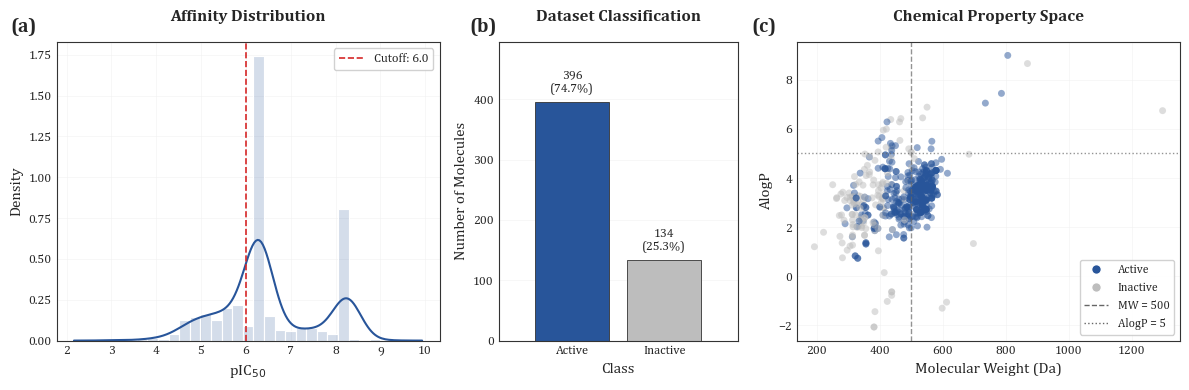

Professional EDA plots saved in EDA_plots_publish


In [20]:
# ### 5. Visualization (Optimized for Top Journal Style)
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator

# 1. 数据准备
final_df['label'] = final_df['label'].astype(int)
final_df['label_name'] = final_df['label'].map({1: 'Active', 0: 'Inactive'})

# 2. 全局样式更新 - 严谨的学术风格
mpl.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Cambria', 'Times New Roman'],
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'axes.linewidth': 0.8,

    'axes.grid': True,
    'grid.color': '#F0F0F0',
    'grid.linewidth': 0.5,
    'grid.alpha': 0.7,

    'savefig.dpi': 600,
    'svg.fonttype': 'none'
})

# 指定配色
color_palette = {'Active': '#28559A', 'Inactive': '#BDBDBD'}
highlight_color = '#d62728' # 用于阈值线的深红色

# 创建画布
fig = plt.figure(figsize=(12, 4))
gs = mpl.gridspec.GridSpec(1, 3, width_ratios=[0.8, 0.5, 0.8], figure=fig) #子图宽度

# --- (a) pIC50 Distribution ---
ax0 = fig.add_subplot(gs[0])
# 使用实心填充+KDE曲线增加专业感
sns.histplot(
    final_df['pIC50'], bins=25, stat='density',
    color=color_palette['Active'], alpha=0.2, edgecolor=None, ax=ax0
)
sns.kdeplot(final_df['pIC50'], color=color_palette['Active'], lw=1.5, ax=ax0)

# 阈值线
ax0.axvline(6.0, color=highlight_color, linestyle='--', linewidth=1.2)
threshold_handle = Line2D([0], [0], color=highlight_color, linestyle='--', 
                          lw=1.2, label='Cutoff: 6.0')

ax0.legend(handles=[threshold_handle], frameon=True, loc='upper right', 
           edgecolor='#CCCCCC', framealpha=0.9)

ax0.set_title('Affinity Distribution', fontweight='bold', pad=15)
ax0.set_xlabel('pIC$_{50}$')
ax0.set_ylabel('Density')
ax0.xaxis.set_major_locator(MultipleLocator(1))

# --- (b) Class Balance ---
ax1 = fig.add_subplot(gs[1])
counts = final_df['label_name'].value_counts().reindex(['Active', 'Inactive'])
total = counts.sum()

# 条形图收窄，显得更精致
bar_width = 0.8
bars = ax1.bar(counts.index, counts.values, color=[color_palette['Active'], color_palette['Inactive']], 
               width=bar_width, edgecolor='#333333', linewidth=0.6)

ax1.set_xlim(-0.8, 1.8)

# 标注数值
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + (total*0.02),
             f'{int(height)}\n({100*height/total:.1f}%)',
             ha='center', va='bottom', fontsize=9, fontweight='normal')

ax1.set_title('Dataset Classification', fontweight='bold', pad=15)
ax1.set_ylim(0, max(counts.values) * 1.25) # 留出文字空间
ax1.set_xlabel('Class')
ax1.set_ylabel('Number of Molecules')
ax1.grid(axis='x', visible=False)

# --- (c) Property Space (MW vs AlogP) ---
ax2 = fig.add_subplot(gs[2])
sns.scatterplot(
    x='MW', y='AlogP', hue='label_name', data=final_df,
    palette=color_palette, hue_order=['Active', 'Inactive'],
    s=25, alpha=0.5, edgecolor='none', ax=ax2, legend=False
)

# 阈值虚线
ax2.axvline(500, color='#666666', linestyle='--', linewidth=1, alpha=0.7)
ax2.axhline(5, color='#666666', linestyle=':', linewidth=1, alpha=0.7)

# 统一样式的图例
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Active',
           markerfacecolor=color_palette['Active'], markersize=7),
    Line2D([0], [0], marker='o', color='w', label='Inactive',
           markerfacecolor=color_palette['Inactive'], markersize=7),
    Line2D([0], [0], color='#666666', lw=1, linestyle='--', label='MW = 500'),
    Line2D([0], [0], color='#666666', lw=1, linestyle=':', label='AlogP = 5'),
]
ax2.legend(handles=legend_elements, frameon=True, loc='lower right', fontsize=8.5,
           edgecolor='#CCCCCC', framealpha=0.9)

ax2.set_title('Chemical Property Space', fontweight='bold', pad=15)
ax2.set_xlabel('Molecular Weight (Da)')
ax2.set_ylabel('AlogP')

# --- 统一细节处理 ---
for n, ax in enumerate([ax0, ax1, ax2]):
    # 添加子图编号 (a) (b) (c)
    ax.text(-0.12, 1.08, f'({chr(97+n)})', transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top')
    
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
        spine.set_color('#333333')
    
    ax.tick_params(axis='both', which='major', direction='in', length=3.5, width=0.8)

plt.tight_layout()

# 保存
output_dir = Path("./EDA_plots_publish/")
output_dir.mkdir(parents=True, exist_ok=True)
#fig.savefig(output_dir / "NSD2_EDA_Professional.png", bbox_inches='tight', dpi=600)
fig.savefig(output_dir / "NSD2_EDA_Professional.svg", bbox_inches='tight')

plt.show()
print(f"Professional EDA plots saved in {output_dir}")